# **Telco Customer Churn Analysis**

## Overview
This project analyzes customer churn behavior for a telecommunications company using a dataset of roughly 7,000 customers. The goal is to identify key drivers of churn and build and predictive model to classify customers at risk of leaving

## Project Structuce
- **ETL**: Raw CSV laoded and cleaned into a SQLite database via `etl/load_to_db.py`
- **SQL**: Initial data exploration performed in `sql/exploration_queries.sql`
- **EDA**: Visualizations and statistical summaries to uncover churn patterns
- **Modeling**: Classification models to predict churn with evaluation metrics

## 1. Data Loading
Loading data from the SQLite database created by the ETL pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Connect to database, load customers table into pandas dataframe
conn = sqlite3.connect('../data/telco_churn.db')
df = pd.read_sql('Select * From customers', conn)
conn.close()

## 2. Data Quality Check
Examine data using `data_check` function

In [3]:
import sys
sys.path.append("../")
from utils.data_quality import data_check

data_check(df)

### First Five Rows



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### Last Five Rows



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1
7031,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,0


### Shape of Data



...

### Churn Class Balance



Churn
0    5163
1    1869
Name: count, dtype: int64

Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

### Numeric Column Ranges



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
min,0.0000,1.000000,18.250000,18.800000,0.000000
max,1.0000,72.000000,118.750000,8684.800000,1.000000
mean,0.1624,32.421786,64.798208,2283.300441,0.265785
median,0.0000,29.000000,70.350000,1397.475000,0.000000


## 3. Data Cleaning
Standardizing column formats before EDA

In [4]:
# Convert SeniorCitizen from binary to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

df['SeniorCitizen'].value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

In [5]:
# Separate numeric and categorial columns for EDA
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print('Numeric:', numeric_cols)
print('Categorical:', categorical_cols)

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Categorical: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/7r/_2xhy8_55cbdnb0hrfblg7ph0000gn/T/ipykernel_60109/3609931636.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [6]:
# remove churn (target variable) from numeric column list
numeric_cols = [col for col in numeric_cols if col != 'Churn']

print('Numeric:', numeric_cols)

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']


## 4. Exploratory Data Analysis (EDA)
Visualizing churn patterns across key features identified during SQL exploration

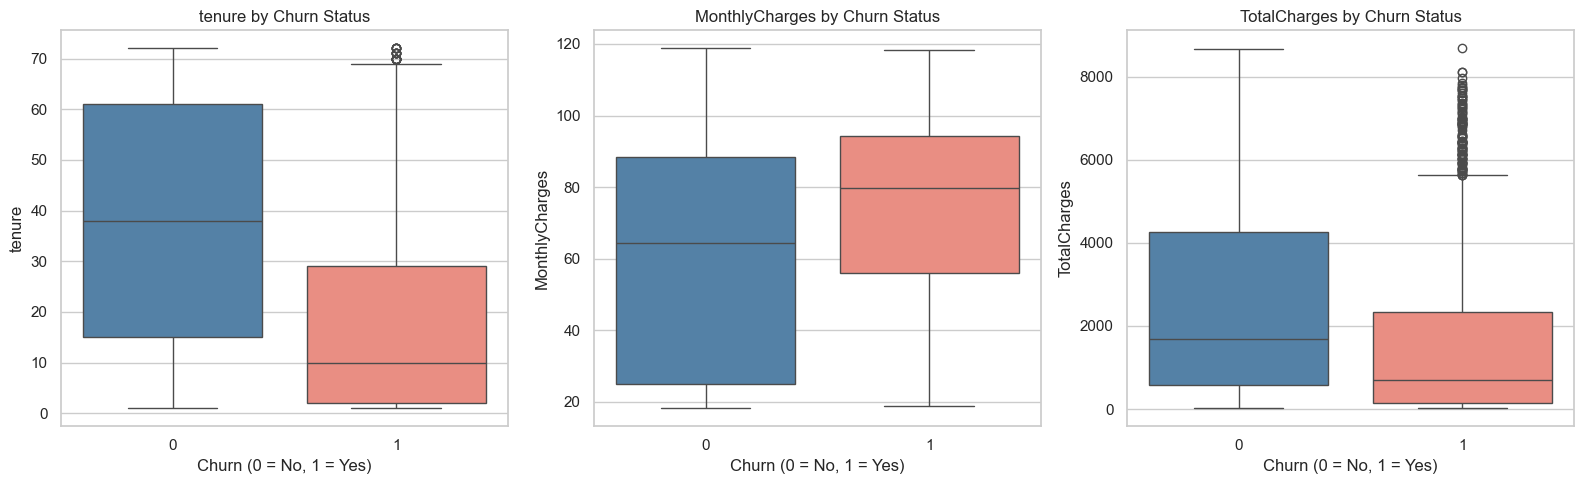

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col,
                hue="Churn", legend=False,
                ax=axes[i], palette={0: "steelblue", 1: "salmon"})
    axes[i].set_title(f"{col} by Churn Status")
    axes[i].set_xlabel("Churn (0 = No, 1 = Yes)")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig("../data/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

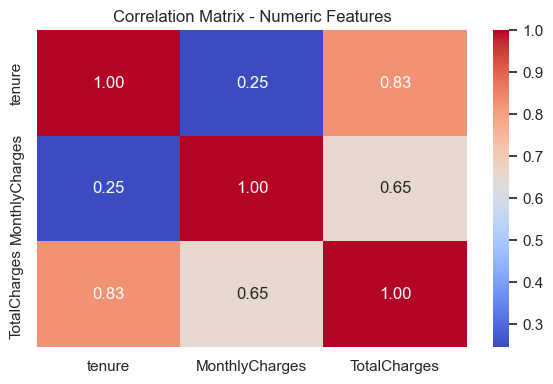

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", 
            cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix - Numeric Features")

plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

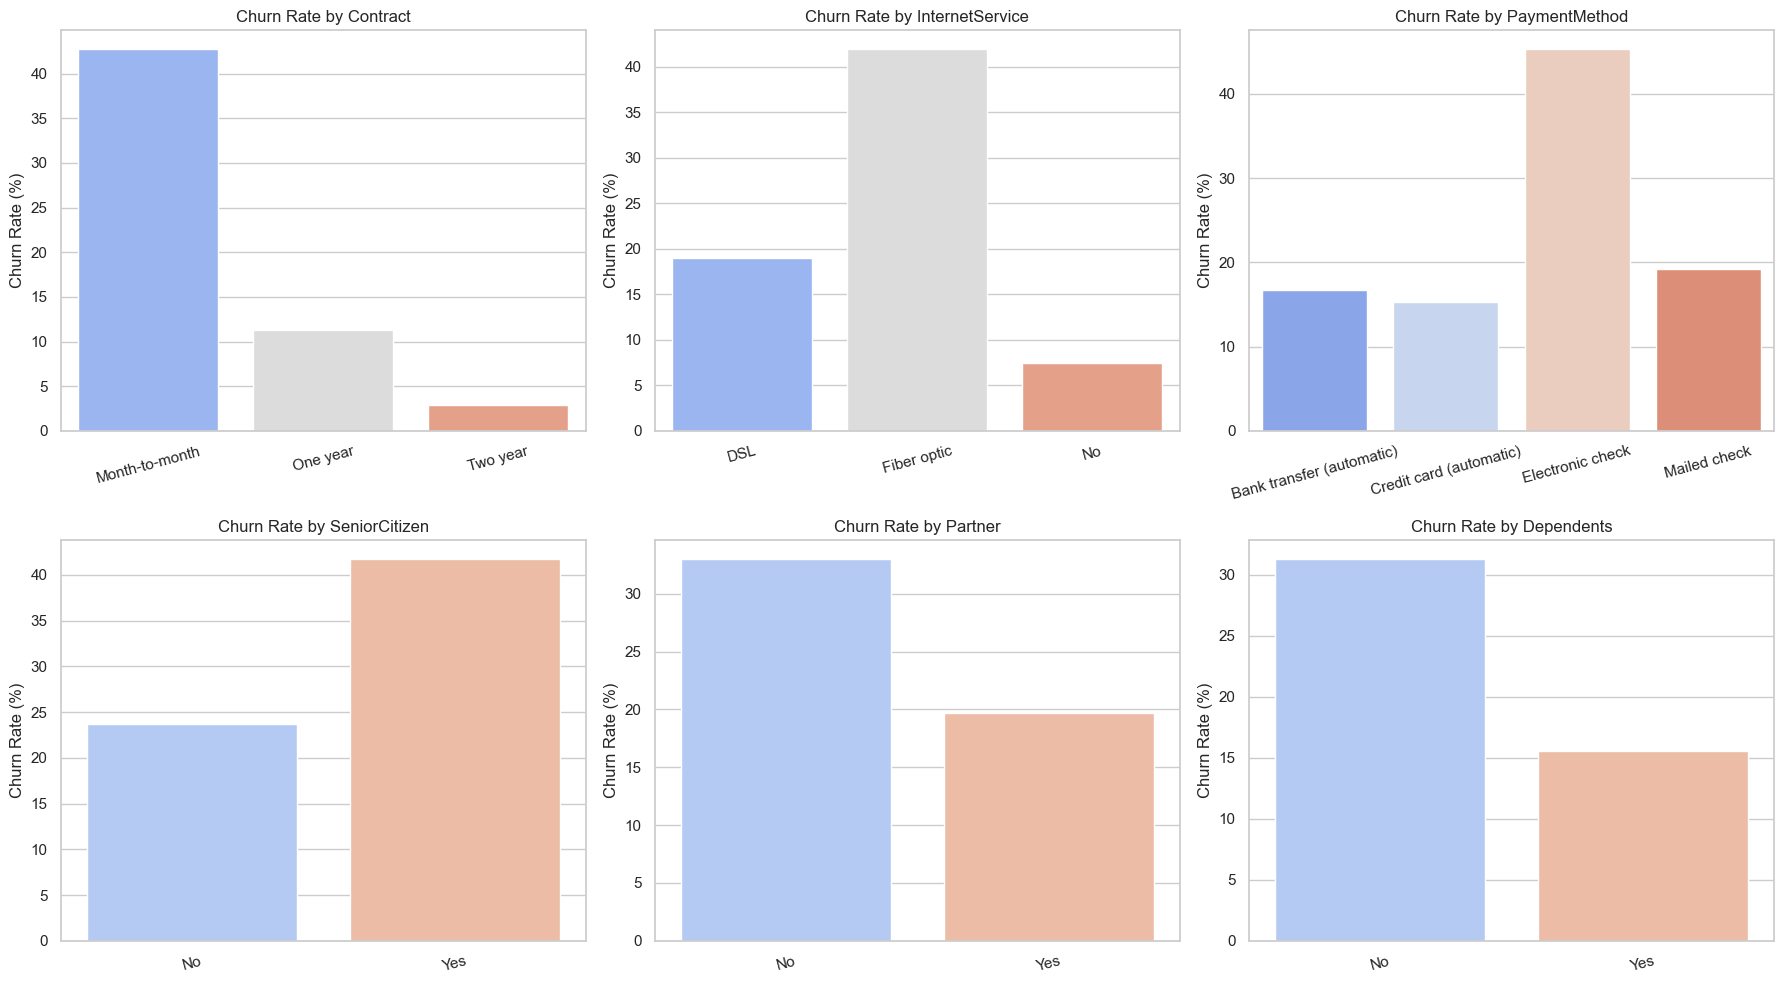

In [9]:
# Churn rate by categorical features
cat_cols_plot = ["Contract", "InternetService", "PaymentMethod", 
                 "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    churn_rate = df.groupby(col)["Churn"].mean().reset_index()
    churn_rate["Churn"] = churn_rate["Churn"] * 100

    sns.barplot(data=churn_rate, x=col, y="Churn",
                hue=col, legend=False,
                ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("../data/categorical_churn_rates.png", dpi=150, bbox_inches="tight")
plt.show()

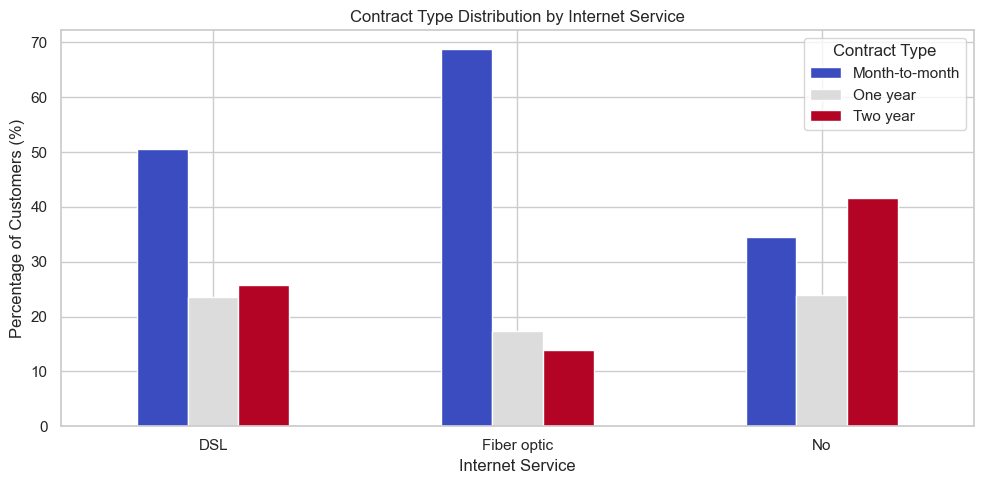

In [10]:
# Internet Service vs Contract Type breakdown
internet_contract = df.groupby(["InternetService", "Contract"]).size().unstack()
internet_contract_pct = internet_contract.div(internet_contract.sum(axis=1), axis=0) * 100

internet_contract_pct.plot(kind="bar", figsize=(10, 5), colormap="coolwarm", edgecolor="white")
plt.title("Contract Type Distribution by Internet Service")
plt.ylabel("Percentage of Customers (%)")
plt.xlabel("Internet Service")
plt.xticks(rotation=0)
plt.legend(title="Contract Type")
plt.tight_layout()
plt.savefig("../data/internet_vs_contract.png", dpi=150, bbox_inches="tight")
plt.show()

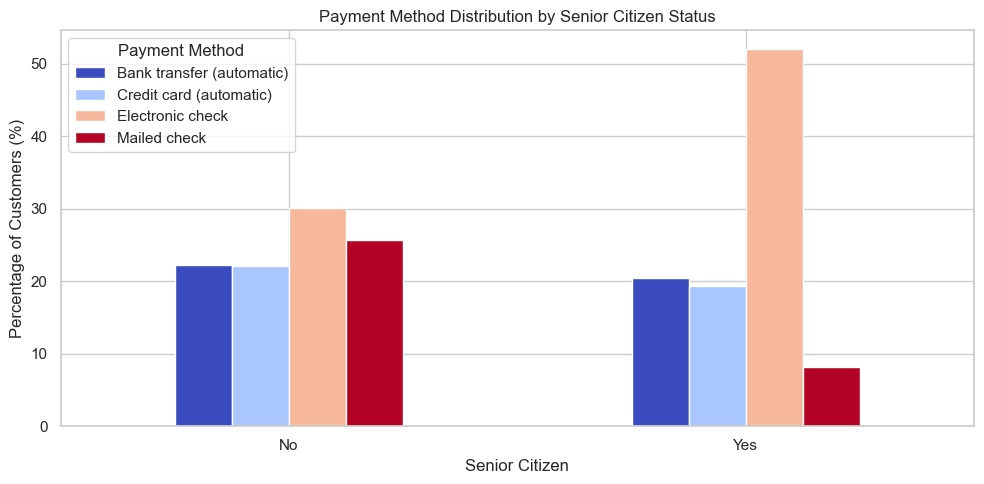

In [11]:
# Senior Citizen vs Payment Method breakdown
senior_payment = df.groupby(["SeniorCitizen", "PaymentMethod"]).size().unstack()
senior_payment_pct = senior_payment.div(senior_payment.sum(axis=1), axis=0) * 100

senior_payment_pct.plot(kind="bar", figsize=(10, 5), colormap="coolwarm", edgecolor="white")
plt.title("Payment Method Distribution by Senior Citizen Status")
plt.ylabel("Percentage of Customers (%)")
plt.xlabel("Senior Citizen")
plt.xticks(rotation=0)
plt.legend(title="Payment Method")
plt.tight_layout()
plt.savefig("../data/senior_vs_payment.png", dpi=150, bbox_inches="tight")
plt.show()

#### EDA Insights - Categorical

**Contract Type**
Customers on month-to-month contracts churn at a significantly higher rate than those 
on one or two year contracts. This is likely driven by two factors: longer contracts 
create a structural lock-in effect, and customers who commit to longer terms typically 
receive discounted rates, making the service feel more palatable.

**Payment Method**
Customers using automatic payment methods such as bank transfers and credit cards churn 
at a much lower rate than those paying manually. This is consistent with a "set it and 
forget it" behavioral pattern — automatic payments remove the monthly decision point that 
might otherwise prompt a customer to reconsider their subscription. Electronic check users 
show a notably higher churn rate than mailed check users, possibly indicating a more 
price-sensitive and actively engaged customer segment who regularly evaluates their 
subscription.

**Internet Service**
Customers using fiber optic internet churn at a dramatically higher rate relative to DSL 
and non-internet users. Fiber is the premium tier with the highest monthly cost, and 
almost 70% of fiber optic customers hold month-to-month contracts — compared to ~50% of 
DSL customers and ~35% of non-internet subscribers. The compounding effect of premium 
pricing with no lock-in helps explain the elevated churn rate among fiber optic users.

**Other Demographics**
Senior citizens churn at a higher rate than non-seniors. I hypothesized that seniors 
disproportionately avoid automatic payments, which was only partially supported by the 
data. However, seniors use electronic check as their primary payment method over 50% of 
the time. Given that electronic check customers show the highest churn rate of any payment 
method, this preference likely contributes to elevated churn among seniors. Customers 
without partners or dependents also show higher churn, likely reflecting less financial 
inertia and fewer household considerations when making the decision to switch providers.

## 5. Feature Engineering & Encoding
Preparing data for modeling by encoding categorical variables, dropping redundant features, and splitting into train/test sets

In [ ]:
# Drop customerID (identifier, not a feature) and TotalCharges (multicollinearity)
df_model = df.drop(columns=["customerID", "TotalCharges"])

# Encode gender first (uses Male/Female not Yes/No)
df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0})

# Encode remaining binary Yes/No columns (excluding gender and Churn)
binary_cols = [col for col in df_model.columns 
               if df_model[col].nunique() == 2 
               and col not in ["Churn", "gender"]]

for col in binary_cols:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0})

# Verify no nulls
print(df_model.isnull().sum())
print("\nRemaining object columns:")
print(df_model.select_dtypes(include="object").columns.tolist())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64

Remaining object columns:
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


/var/folders/7r/_2xhy8_55cbdnb0hrfblg7ph0000gn/T/ipykernel_60109/433958687.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_model.select_dtypes(include="object").columns.tolist())


In [13]:
# One-hot encode remaining categorical columns
df_model = pd.get_dummies(df_model, 
                           columns=["MultipleLines", "InternetService", 
                                    "OnlineSecurity", "OnlineBackup", 
                                    "DeviceProtection", "TechSupport", 
                                    "StreamingTV", "StreamingMovies", 
                                    "Contract", "PaymentMethod"],
                           drop_first=True)

print(df_model.shape)
print(df_model.dtypes)

(7032, 30)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSuppo

In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Train/test split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nChurn rate in training set: {y_train.mean():.3f}")
print(f"Churn rate in test set: {y_test.mean():.3f}")

Training set: (5625, 29)
Test set: (1407, 29)

Churn rate in training set: 0.266
Churn rate in test set: 0.266


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Columns to scale
scale_cols = ["tenure", "MonthlyCharges"]

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])